In [1]:
"""
This file only works for 3D slice by slice inference.
"""

import os
import sys

#import opensimplex

#from torchvision.utils import save_image

import matplotlib.pyplot as plt
import numpy as np
import torch
from monai.utils import set_determinism
from torch.amp import autocast
from tqdm import tqdm
import nibabel as nib
from scipy import stats
import json
import argparse
from monai.networks.schedulers import DDPMScheduler

from pathlib import Path
import pandas as pd

from utils.compute_select_params_cpu import launch_compute_select_params_cpu


import utils.simplex_ddpm as simplex_ddpm
import utils.scores as scores

from utils.utils import *
from datasets import anomaly_datasets

from scipy.ndimage import median_filter, binary_erosion, binary_dilation, binary_fill_holes


DEVICE_TYPE = "cuda:0"


In [2]:
EXPERIMENT_DIR = Path("./experiment_2/exp_2_2")
CONFIG_PATH = EXPERIMENT_DIR / "config.json"
MODEL_PATH = EXPERIMENT_DIR / "models" / "exp_2_2_best_model.pth"

if not CONFIG_PATH.exists():
    raise FileNotFoundError(f"Could not find config at {CONFIG_PATH.resolve()}")
if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Could not find model at {MODEL_PATH.resolve()}")

with open(CONFIG_PATH, "r") as f:
    config = json.load(f)

# "args" namespace compatible with define_instance() and dataset classes.
args = argparse.Namespace(**config)

configured_root = Path(str(args.root_dir))
repo_root = Path.cwd().resolve()
if repo_root.name == "2d_ddpm":
    repo_root = repo_root.parent

if configured_root.exists():
    root_dir = configured_root
else:
    root_dir = repo_root.parent

args.root_dir = str(root_dir) + "/"
print(f"Loaded config: {CONFIG_PATH}")
print(f"Using root_dir: {args.root_dir}")
print(f"Model path: {MODEL_PATH}")

Loaded config: experiment_2/exp_2_2/config.json
Using root_dir: /bettik/PROJECTS/pr-gin5_aini/fehrdelt/
Model path: experiment_2/exp_2_2/models/exp_2_2_best_model.pth


peut être différence dans anomaly_dataset entre ano_dataset.get_anomaly_loader_select_params(group) et ano_dataset.get_anomaly_images_select_params(group), 

vu que j'ai pas la même facon de slice -> regarder si c'est bien les mêmes images

In [29]:
import copy
import sys
sys.path.append("../..")

import numpy as np
import torch
import AnoDDPM.simplex as simplex
import utils.simplex_ddpm as simplex_ddpm
import utils.thor_ddpm as thor_ddpm
from utils.utils import scale_intensity_from_histogram_peak
from utils.utils import dtprint


@torch.no_grad()
def my_sample(args, model, device, image, infer_scheduler, timesteps, return_intermediates=False):
    
    simplexObj = simplex.Simplex_CLASS()

    if args.noise["type"] == "simplex":
        noise = simplex_ddpm.generate_simplex_noise(simplexObj, image.shape, normalize=args.noise["normalize"]).to(device)
    if args.noise["type"] == "gaussian":
        noise = torch.randn(image.shape).to(device)
    

    if timesteps >= infer_scheduler.num_train_timesteps:
        dtprint(timesteps, "is too high. Setting to", infer_scheduler.num_train_timesteps-1)

    timesteps_list = torch.Tensor([timesteps for a in range(image.shape[0])]).to(image.device).long()

    image = infer_scheduler.add_noise(image, noise, timesteps_list).to(device) #TODO


    intermediates = []
    intermediates_step = 20

    for t in range(timesteps, 0, -1): # va de timesteps à 0
        
        model_output = model(
            image, timesteps=torch.Tensor((t,)).to(device), context=None
        )
        #print(model_output.shape)
        
        image, _ = infer_scheduler.step(model_output, t, image)
    
        if (t== timesteps-1 or t%intermediates_step == 0) and return_intermediates:
            intermediates.append(image)

    if return_intermediates:
        return image, intermediates
    else:
        return image



In [14]:
group = "large"

In [15]:
ano_dataset = anomaly_datasets.SOOP(args, batch_size=32, num_workers=4, groups_to_load=[group], pin_memory=True)

Loading dataset: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 116/116 [00:17<00:00,  6.80it/s]


In [16]:
image_loader = ano_dataset.get_anomaly_loader_metrics(group)
image_paths = ano_dataset.get_anomaly_images_metrics(group)

In [17]:
DEVICE_TYPE = "cuda:0"
device = torch.device(DEVICE_TYPE)

In [18]:
nb_inferences=2

In [19]:
timesteps = 90

[2026-04-22 18:00:13] Processing batch 1/2


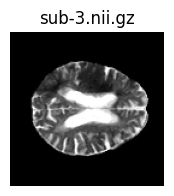

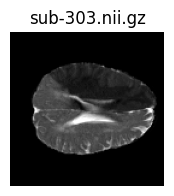

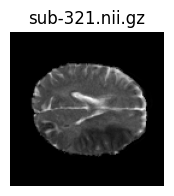

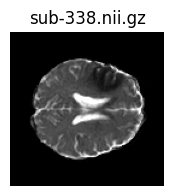

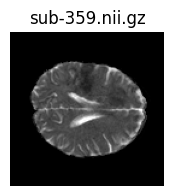

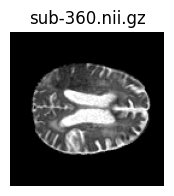

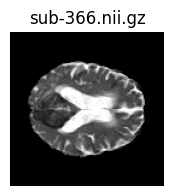

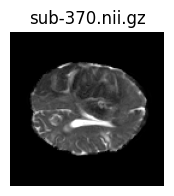

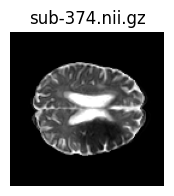

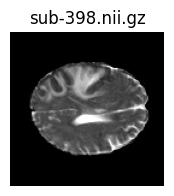

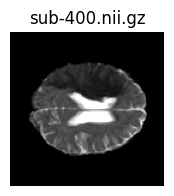

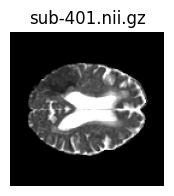

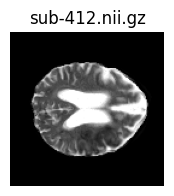

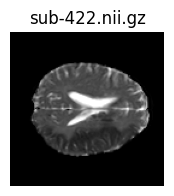

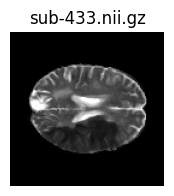

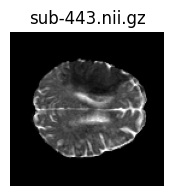

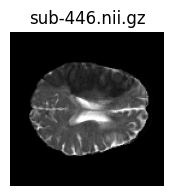

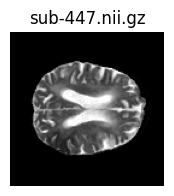

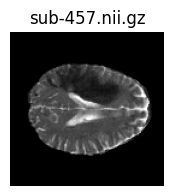

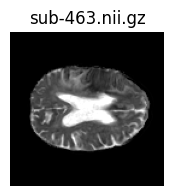

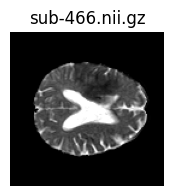

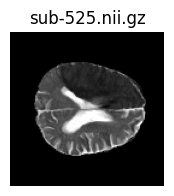

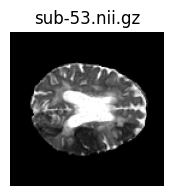

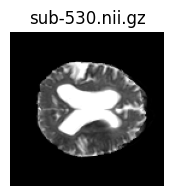

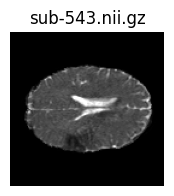

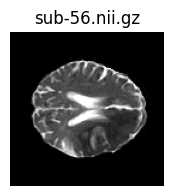

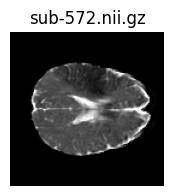

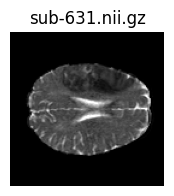

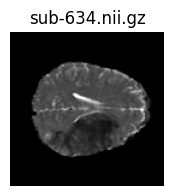

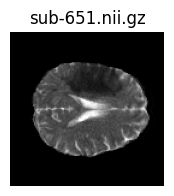

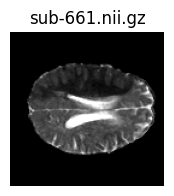

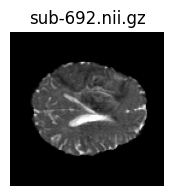

[2026-04-22 18:00:19] Processing batch 2/2


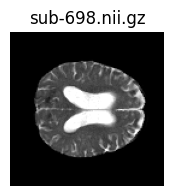

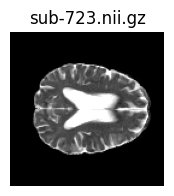

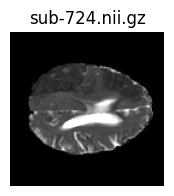

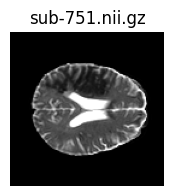

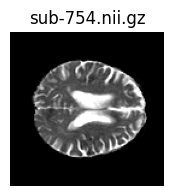

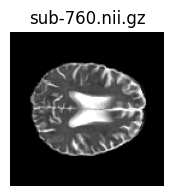

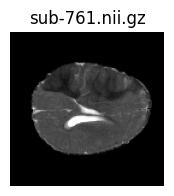

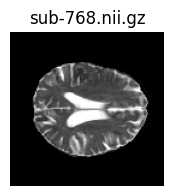

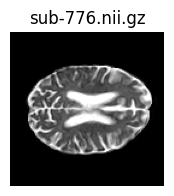

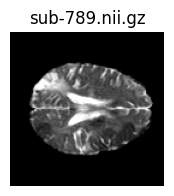

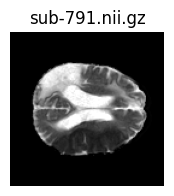

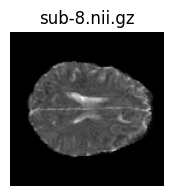

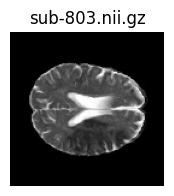

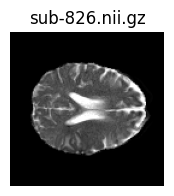

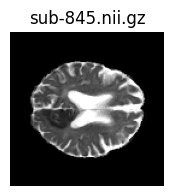

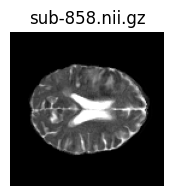

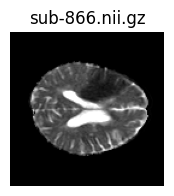

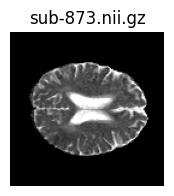

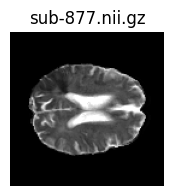

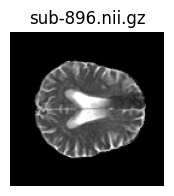

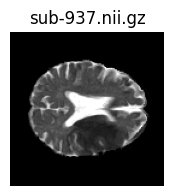

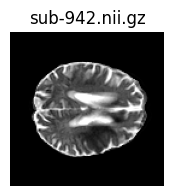

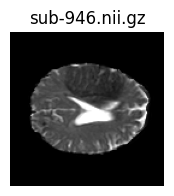

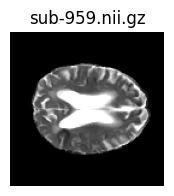

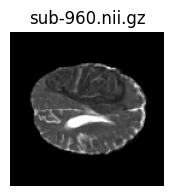

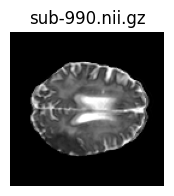

In [25]:

for i, image_batch in enumerate(image_loader):
    dtprint(f"Processing batch {i+1}/{len(image_loader)}")
    test_images = image_batch.to(device)

    def process_batch():

        infered_images = []

        """
        for inference_idx in range(nb_inferences):
            infered_slices = []
            dtprint(f"Inference {inference_idx+1}/{nb_inferences} for batch {i+1}/{len(image_loader)}")

            # infer slice by slice
            for slice_idx in range(args.slice_indexes_start, args.slice_indexes_end):
                    
                infered_slice = my_sample(args, model, device, test_images[...,slice_idx], infer_scheduler, timesteps=timesteps, return_intermediates=False)
                
                infered_slices.append(infered_slice.unsqueeze(-1))

            # stack the slices back to a 3D volume
            infered_images.append(torch.cat(infered_slices, dim=-1))
        
        average_infered_image = torch.mean(torch.stack(infered_images, dim=0), dim=0)
        

        # go through infered images in the batch
        for b in range(average_infered_image.shape[0]):
            average_infered_image[b] = torch.clamp(scale_intensity_from_histogram_peak(average_infered_image[b], 2.0/7.0), 0.0, 1.0)

        # make the anomaly map (difference between infered and original)
        final_anomaly_map = torch.zeros_like(test_images)
        final_anomaly_map[...,args.slice_indexes_start:args.slice_indexes_end] = torch.abs(average_infered_image - test_images[...,args.slice_indexes_start:args.slice_indexes_end])
        """

        # save the images
        for idx_in_batch in range(test_images.shape[0]):
            image_id = i*image_loader.batch_size + idx_in_batch
            image_name = os.path.basename(image_paths[image_id])

            #output_path = output_folder+f"{image_name.split('.')[0]}_t_{timesteps}.nii.gz"

            img_np = test_images[idx_in_batch].detach().cpu().squeeze().numpy()
            axial_idx = img_np.shape[-1] // 2  # middle axial slice

            plt.figure(figsize=(2, 2))
            plt.imshow(img_np[..., axial_idx], cmap="gray")
            plt.title(image_name)
            plt.axis("off")
            plt.show()

            #if the output file doesn't exist already
            """
            if not os.path.exists(output_path) or replace_existing_files: # if just one file is missing, we need to process the batch
                dtprint(f"Saving anomaly map for image {image_name} at {output_path}")
                nib.save(nib.Nifti1Image(final_anomaly_map[idx_in_batch].squeeze().cpu().numpy(), basic_affine), output_path)
            """

        
    if True:
        process_batch()
    """else:
        
        for idx_in_batch in range(test_images.shape[0]):
            image_id = i*test_images.shape[0] + idx_in_batch
            image_name = os.path.basename(image_paths[image_id])
            output_path = output_folder+f"{image_name.split('.')[0]}_t_{timesteps}.nii.gz"
            #if the output file doesn't exist already
            if not os.path.exists(output_path): # if just one file is missing, we need to process the batch
                process_batch()
                break"""

In [22]:
print(test_images.shape[0])

26


In [24]:
print(image_loader.batch_size)

32
